In [1]:
%load_ext autoreload
%autoreload 2
import tightbinding_system as tbs
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from copy import deepcopy
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import eigsh
funcs = [
        lambda x : x%(2*np.pi),
        np.cos,
        lambda x : np.abs(np.cos(x))
        ]

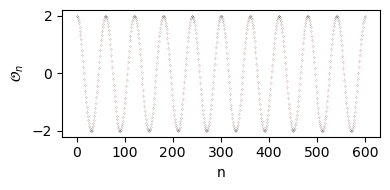

In [234]:
parameters = {
    "V1": 1, # onsite energy magnitude
    "V2": 1, # hopping energy
    "Theta_numerator": 10, # spectrum function iterates over it anyways -> 2pi*Theta_numerator/Theta_denominator*x is an argument of an onsite scaling funcion
    "Theta_denominator": 601, # determines size of the Hamiltonian matrix -> "how many points for a full cycle of onsite energy"
    "nu": 0, # phase factor for onsite scaling function
    "k": 0, # wave vector

    "periodic_function": funcs[1] # periodic function (onsite scaling funcion)
    }

sys = tbs.makesystem(parameters, plot_onsite=True, name = "system")

# widmo w funkcji V2

- po prostu widmo

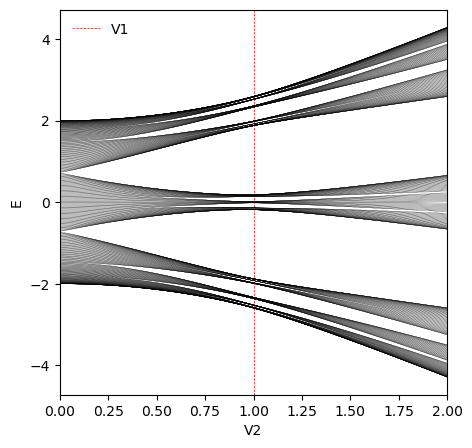

In [ ]:
parameters = {
    "V1": 1, # onsite energy magnitude
    "V2": 1, # hopping energy
    "Theta_numerator": 230, # spectrum function iterates over it anyways -> 2pi*Theta_numerator/Theta_denominator*x is an argument of an onsite scaling funcion
    "Theta_denominator": 601, # determines size of the Hamiltonian matrix -> "how many points for a full cycle of onsite energy"
    "nu": 0, # phase factor for onsite scaling function
    "k": 0, # wave vector

    "periodic_function": funcs[1] # periodic function (onsite scaling funcion)
    }

v2_linspace = np.linspace(0, 2, 90)
pm_local = deepcopy(parameters)
energies = []
for idxv2, v2 in enumerate(v2_linspace):
    pm_local["V2"] = v2
    h = tbs.makesystem(pm_local, False)
    energies.append(eigh(h, eigvals_only=True, subset_by_value=None))
energies = np.array(energies)

fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.set_ylabel("E")
ax.set_xlabel("V2")
ax.axvline(x=pm_local["V1"], color='r', linestyle='--', linewidth=0.5, label = "V1")
ax.legend(frameon = False)
ax.set_xlim(v2_linspace.min(), v2_linspace.max())
for en in energies.T:
    ax.plot(v2_linspace, en, '-', color = 'k', linewidth = 0.1)
plt.savefig("EV2.pdf")
plt.show()

- animacja

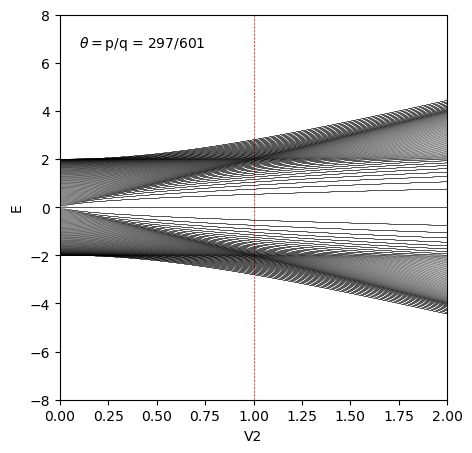

In [86]:
parameters = {
    "V1": 1,
    "V2": 1,
    "Theta_numerator": 1,
    "Theta_denominator": 601,
    "nu": 0,
    "k": 0,
    "periodic_function": funcs[1]
}

v2_linspace = np.linspace(0, 2, 90)
tn_linspace = np.arange(1, 301, 4)

fig, ax = plt.subplots(figsize=(5, 5))
def update(tn):
    pm_local = deepcopy(parameters)
    pm_local["Theta_numerator"] = tn

    energies = []
    for v2 in v2_linspace:
        pm_local["V2"] = v2
        h = tbs.makesystem(pm_local, False)
        energies.append(eigh(h, eigvals_only=True))
    
    energies = np.array(energies)
    ax.clear()
    ax.set_ylabel("E")
    ax.set_xlabel("V2")
    ax.axvline(x=pm_local["V1"], color='r', linestyle='--', linewidth=0.5)
    ax.set_xlim(v2_linspace.min(), v2_linspace.max())
    ax.text(0.05, 0.95, r"$\theta = $" + f"p/q = {pm_local['Theta_numerator']}/{pm_local['Theta_denominator']}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left')
    num_bands = energies.shape[1]
    xx = np.tile(v2_linspace, (num_bands, 1))
    yy = energies.T
    segments = np.stack((xx, yy), axis=2)

    lc = LineCollection(segments, colors='k', linewidths=0.1, rasterized=True) # type: ignore
    ax.add_collection(lc)
    ax.set_ylim(-8, 8)

ani = FuncAnimation(fig, update, frames=tn_linspace) # type: ignore
ani.save('widmo_w_funkcji_p.gif', writer='pillow', fps=5)
plt.show()

- widmo ale z IPR

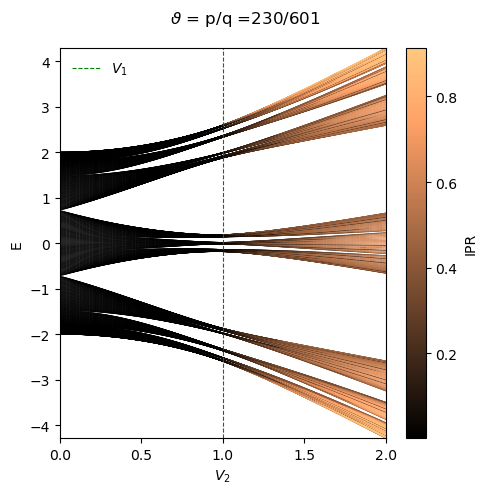

In [ ]:
parameters = {
    "V1": 1, 
    "V2": 1, 
    "Theta_numerator": 230, 
    "Theta_denominator": 601, 
    "nu": 0, 
    "k": 0, 
    "periodic_function": funcs[1] 
}

v2_linspace = np.linspace(0, 2, 100)
pm_local = deepcopy(parameters)

energies_list = []
ipr_list = []
for v2 in v2_linspace:
    pm_local["V2"] = v2
    h = tbs.makesystem(pm_local, False)
    vals, vecs = eigh(h)
    psi_sq = np.abs(vecs)**2
    ipr = np.sum(psi_sq**2, axis=0)
    energies_list.append(vals)
    ipr_list.append(ipr)

energies = np.array(energies_list).T
iprs = np.array(ipr_list).T

X = np.tile(v2_linspace, (energies.shape[0], 1))
Y = energies
points = np.array([X, Y]).T.swapaxes(0, 1)
segments = np.stack([points[:, :-1], points[:, 1:]], axis=2)
segments = segments.reshape(-1, 2, 2)
segment_colors = (iprs[:, :-1] + iprs[:, 1:])/2
segment_colors = segment_colors.flatten()

fig, ax = plt.subplots(figsize=(5, 5))
lc = LineCollection(segments, cmap='copper', rasterized=True) #type:ignore
lc.set_array(segment_colors)
lc.set_linewidth(0.5)
ax.add_collection(lc)
ax.set_xlim(v2_linspace.min(), v2_linspace.max())
ax.set_ylim(energies.min(), energies.max())
ax.set_xlabel(r"$V_2$")
ax.set_ylabel("E")
ax.axvline(x=pm_local["V1"], color='g', linestyle='--', linewidth=0.8, label=r"$V_1$")
ax.legend(loc='upper left', frameon=False)
cbar = plt.colorbar(lc, ax=ax)
cbar.set_label(r"IPR")
fig.suptitle(r"$\vartheta$ = p/q =" + f"{pm_local["Theta_numerator"]}/{pm_local["Theta_denominator"]}")
plt.tight_layout()
plt.savefig("EV2.pdf")
plt.show()

# funkcje falowe
zdelokalizowana (V2 < V1), zlokalizowana (V2 > V1)


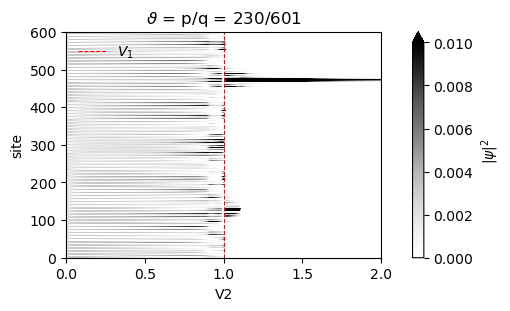

In [13]:
parameters = {
    "V1": 1,
    "V2": 1,
    "Theta_denominator": 601,
    "nu": 0,
    "k": 0,
    "periodic_function": funcs[1]
}

Tn_list = [230,]
Tn_list.sort()
v2_linspace = np.linspace(0, 2, 400)
fig, axes = plt.subplots(1, len(Tn_list), figsize=(5, 3), sharey=True, constrained_layout=True)
for idx, (tn, ax) in enumerate(zip(Tn_list, [axes,])):
    pm_local = deepcopy(parameters)
    pm_local["Theta_numerator"] = tn
    wavefunctions_map = []
    for v2 in v2_linspace:
        pm_local["V2"] = v2
        h_dense = tbs.makesystem(pm_local, False)
        h_sparse = csc_matrix(h_dense)
        vals, vecs = eigsh(h_sparse, k=1, sigma=0, which='LM')
        
        psi_sq = np.abs(vecs[:, 0])**2
        wavefunctions_map.append(psi_sq)

    wavefunctions_map = np.array(wavefunctions_map).T
    im = ax.imshow(
        wavefunctions_map, 
        aspect='auto', 
        origin='lower', 
        extent=(v2_linspace.min(), v2_linspace.max(), 0, parameters["Theta_denominator"]), 
        cmap='Greys', 
        interpolation='nearest',
        rasterized=True,
        vmin=0,
        vmax=0.01
    )
    
    ax.set_title(rf"$\vartheta$ = p/q = {tn}/{parameters["Theta_denominator"]}")
    ax.set_xlabel("V2")
    if idx == 0:
        ax.set_ylabel("site")
    ax.axvline(x=parameters["V1"], color='r', linestyle='--', linewidth=0.8, label=r"$V_1$")
    ax.legend(loc='upper left', frameon=False)

cbar = fig.colorbar(im, ax=axes, extend='max') #, fraction=0.02, pad=0.02) #type:ignore
cbar.set_label(r'$|\psi|^2$')

plt.savefig("phase_transition.pdf")
plt.show()

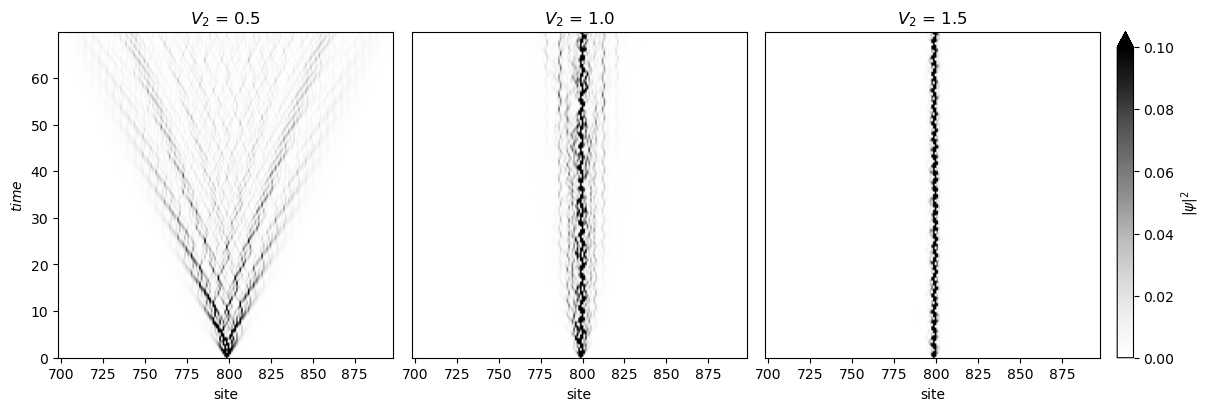

In [231]:
v2_values = [0.5, 1.0, 1.5]
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for idx, v2 in enumerate(v2_values):
    
    parameters = {
        "V1": 1.0,
        "V2": v2,
        "Theta_numerator": 987,
        "Theta_denominator": 1597,
        "nu": 0,
        "k": 0,
        "periodic_function": np.cos
    }

    N = parameters["Theta_denominator"]
    h_dense = tbs.makesystem(parameters, False) 
    psi_0 = np.zeros(N, dtype=complex)
    psi_0[N//2] = 1.0 + 0j

    t, psi_t = tbs.CrankNicolson(psi_0, h_dense, dt = 0.05, n_t=1400)

    ax = axs[idx]
    im = axs[idx].imshow(
        np.abs(psi_t)**2, 
        aspect='auto', 
        origin='lower', 
        extent=[0, N, 0, t.max()],
        cmap='Grays',
        vmin=0, vmax=0.1
    )
    
    axs[idx].set_xlim(N//2 - 100, N//2 + 100)
    axs[idx].set_title(rf"$V_2$ = {v2}")
    axs[idx].set_xlabel("site")

    if idx != 0:
        axs[idx].set_yticks([])
    if idx == 0:
        axs[idx].set_ylabel(r"$time$")
    if idx == 2:
        cb = plt.colorbar(im, ax=axs[idx], extend = 'max')
        cb.set_label(r"$|\psi|^2$")

plt.savefig("time_evolution.pdf")
plt.show()

# Widmo w funkcji $\theta$

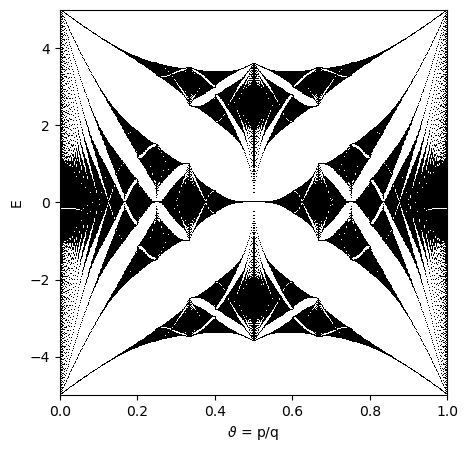

In [20]:
parameters = {
    "V1": 1, # onsite energy magnitude
    "V2": 1.5, # hopping energy
    "Theta_numerator": 0, # spectrum function iterates over it anyways -> 2pi*Theta_numerator/Theta_denominator*x is an argument of an onsite scaling funcion
    "Theta_denominator": 601, # determines size of the Hamiltonian matrix -> "how many points for a full cycle of onsite energy"
    "nu": 0, # phase factor for onsite scaling function
    "k": 0, # wave vector

    "periodic_function": funcs[1] # periodic function (onsite scaling funcion)
    }

thetas, energies = tbs.spectrum(
    pm = parameters,
    makesystem = tbs.makesystem,
    step=1, # step of the Theta_numerator [0->Theta_denominator]
    plot=True, # whether to plot E(phase)
    name = "V1V2different"
    )

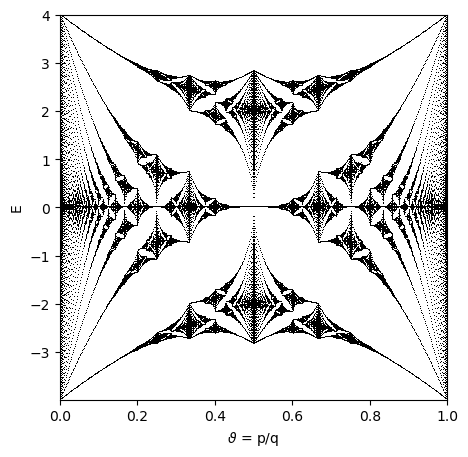

In [74]:
parameters = {
    "V1": 1, # onsite energy magnitude
    "V2": 1, # hopping energy
    "Theta_numerator": 230, # spectrum function iterates over it anyways -> 2pi*Theta_numerator/Theta_denominator*x is an argument of an onsite scaling funcion
    "Theta_denominator": 601, # determines size of the Hamiltonian matrix -> "how many points for a full cycle of onsite energy"
    "nu": 0, # phase factor for onsite scaling function
    "k": 0, # wave vector

    "periodic_function": funcs[1] # periodic function (onsite scaling funcion)
    }

thetas, energies = tbs.spectrum(
    pm = parameters,
    makesystem = tbs.makesystem,
    step=1, # step of the Theta_numerator [0->Theta_denominator]
    plot=True, # whether to plot E(phase)
    name = "V1V2same"
    )

# multifraktalny wymiar dla całego zbioru E - nic mądrego

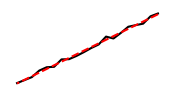

dim = 3.1414515364816338
error = 0.05648669541089694


In [90]:
dim, err = tbs.md(energies, q=5, power_of_2point3_minmax = (2, 7),
                        nsteps = 20, plot = True)
print("dim =", dim)
print("error =", err)

# wymiar multifraktalny (q=2) w funkcji $\theta$ - przykładowy

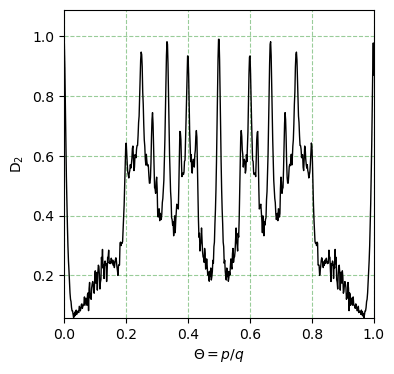

In [91]:
md = tbs.multifractal_dimension(
    thetas, 
    energies, 
    q = 2,
    power_of_2point3_minmax = (4, 10),
    nsteps = 20,
    histrange = None,
    
    plot=True,
    errorbar = False
) 

# wymiar multifraktalny w funkcji q oraz $\theta$

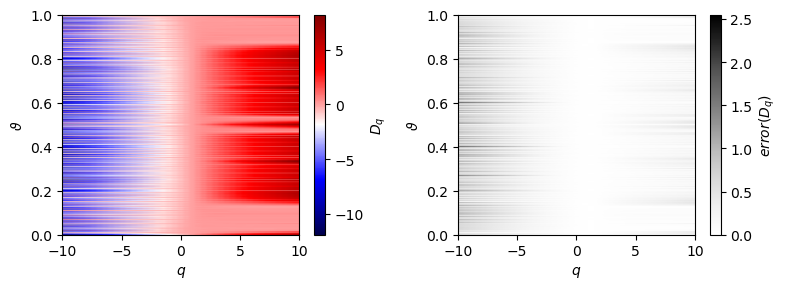

In [62]:
parameters = {
    "V1": 1, # onsite energy magnitude
    "V2": 1, # hopping energy
    "Theta_numerator": 230, # spectrum function iterates over it anyways -> 2pi*Theta_numerator/Theta_denominator*x is an argument of an onsite scaling funcion
    "Theta_denominator": 601, # determines size of the Hamiltonian matrix -> "how many points for a full cycle of onsite energy"
    "nu": 0, # phase factor for onsite scaling function
    "k": 0, # wave vector

    "periodic_function": funcs[1] # periodic function (onsite scaling funcion)
    }

q_linspace = np.arange(-10, 10.1, 0.5)
mds, mdserr = (np.zeros((len(thetas), len(q_linspace))) for _ in range(2))
for idxq, q in enumerate(q_linspace):
    _, mds[:, idxq], mdserr[:, idxq] = tbs.multifractal_dimension(
                                    thetas, 
                                    energies, 
                                    q = q,
                                    power_of_2point3_minmax = (4, 10),
                                    nsteps = 20,
                                    histrange = None,
                                    plot=False
                                    )

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
c = ax[0].imshow(mds, extent=(q_linspace.min(), q_linspace.max(), thetas.min(), thetas.max()),
                aspect='auto', origin='lower', cmap='seismic')
d = ax[1].imshow(mdserr, extent=(q_linspace.min(), q_linspace.max(), thetas.min(), thetas.max()),
                aspect='auto', origin='lower', cmap='Greys')
ax[0].set_xlabel(r'$q$')
ax[1].set_xlabel(r'$q$')
ax[0].set_ylabel(r'$\vartheta$')
ax[1].set_ylabel(r'$\vartheta$')
fig.colorbar(c, ax=ax[0], label=r'$D_q$')
fig.colorbar(d, ax=ax[1], label=r'$error(D_q)$')
fig.tight_layout()
plt.savefig("multifractal_dimension.pdf")
plt.show()

# wymiar multifraktalny w funkcji V2 i $\theta$ (dla q w Q)

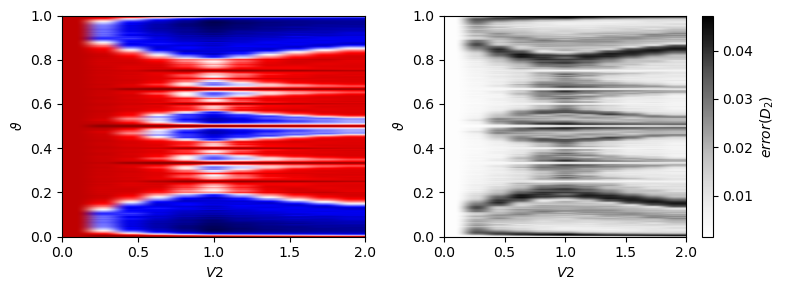

In [63]:
pm_local = deepcopy(parameters)

#####################################
Q = [2]
V2_linspace = np.arange(0, 2.1, 0.2)
#####################################

mds, mdserr = [], []
for idxv2, v2 in enumerate(V2_linspace):
    pm_local["V2"] = v2
    thetas, energies = tbs.spectrum(
                                    pm = pm_local,
                                    makesystem = tbs.makesystem,
                                    step=1, # step of the Theta_numerator [0->Theta_denominator]
                                    plot=False # whether to plot E(phase)
                                    )
    if idxv2 == 0:
        # bad place for a declaration but it is the way it is
        mds = [np.zeros((len(thetas), len(V2_linspace))) for _ in range(len(Q))]
        mdserr = [np.zeros((len(thetas), len(V2_linspace))) for _ in range(len(Q))]
    
    for idx_q, _q in enumerate(Q):
        _, mds[idx_q][:, idxv2], mdserr[idx_q][:, idxv2] = tbs.multifractal_dimension(
                                                                                    thetas, 
                                                                                    energies, 
                                                                                    q = _q,
                                                                                    power_of_2point3_minmax = (4, 10),
                                                                                    nsteps = 20,
                                                                                    histrange = None,
                                                                                    plot=False
                                                                                    )


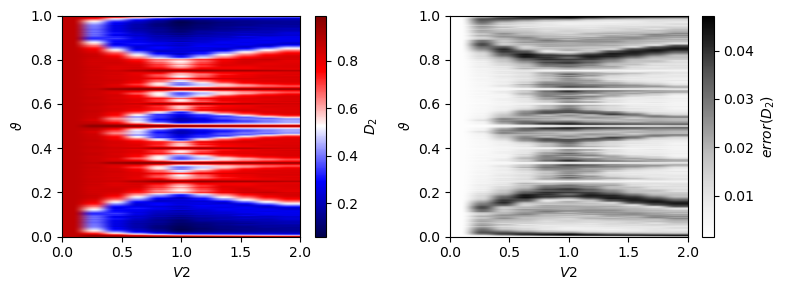

In [65]:
for idx_q, _q in enumerate(Q):

        fig, ax = plt.subplots(1, 2, figsize=(8, 3))
        c = ax[0].imshow(mds[idx_q],
                        extent=(V2_linspace.min(), V2_linspace.max(),
                                thetas.min(), thetas.max()), # type: ignore
                        aspect='auto', origin='lower', cmap='seismic')
        d = ax[1].imshow(mdserr[idx_q],
                        extent=(V2_linspace.min(), V2_linspace.max(),
                                thetas.min(), thetas.max()), # type: ignore
                        aspect='auto', origin='lower', cmap='Greys')
        ax[0].set_xlabel(r'$V2$')
        ax[1].set_xlabel(r'$V2$')
        ax[0].set_ylabel(r'$\vartheta$')
        ax[1].set_ylabel(r'$\vartheta$')
        #fig.suptitle(f"q = {_q}")
        fig.colorbar(c, ax=ax[0], label=rf'$D_{_q}$')
        fig.colorbar(d, ax=ax[1], label=rf'$error(D_{_q})$')
        fig.tight_layout()
        fig.savefig("dim_2.pdf")
        plt.show()

# GENERALIZED SYSTEM

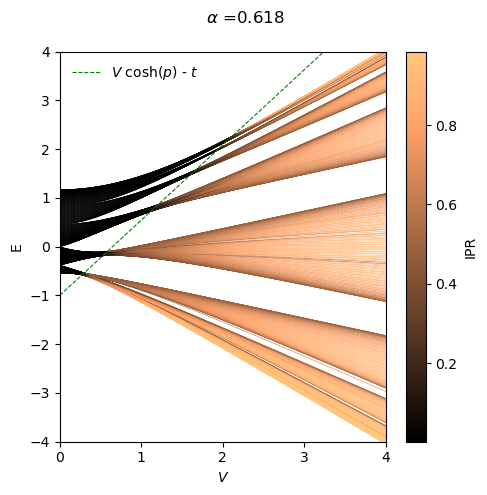

In [68]:
parameters = {
    "V1": 1,
    "V2": 1,
    "Theta_numerator": 170, # usless if alpha is defined

    "alpha": 0.5*(np.sqrt(5) - 1),
    "Theta_denominator": 500,
    
    "nu": 0,
    "k": 0,
    "p": 1,

    "periodic_function": funcs[1]
}

v2_linspace = np.linspace(0, 4, 100)
pm_local = deepcopy(parameters)

energies_list = []
ipr_list = []
for v2 in v2_linspace:
    pm_local["V2"] = v2
    h = tbs.makesystem_Biddle(pm_local, False)
    vals, vecs = eigh(h)
    psi_sq = np.abs(vecs)**2
    ipr = np.sum(psi_sq**2, axis=0)
    energies_list.append(vals)
    ipr_list.append(ipr)

energies = np.array(energies_list).T
iprs = np.array(ipr_list).T

X = np.tile(v2_linspace, (energies.shape[0], 1))
Y = energies
points = np.array([X, Y]).T.swapaxes(0, 1)
segments = np.stack([points[:, :-1], points[:, 1:]], axis=2)
segments = segments.reshape(-1, 2, 2)
segment_colors = (iprs[:, :-1] + iprs[:, 1:])/2
segment_colors = segment_colors.flatten()

fig, ax = plt.subplots(figsize=(5, 5))
lc = LineCollection(segments, cmap='copper', rasterized=True) #type:ignore
lc.set_array(segment_colors)
lc.set_linewidth(0.5)
ax.add_collection(lc)
ax.set_xlim(v2_linspace.min(), v2_linspace.max())

ax.set_xlabel(r"$V$")
ax.set_ylabel("E")
ax.plot(v2_linspace, v2_linspace*np.cosh(parameters["p"]) - parameters["V1"],
        color = 'g', linestyle = '--',linewidth=0.8, label = "$V$ $\cosh(p)$ - $t$")
ax.set_ylim(-4, 4)
ax.legend(loc='upper left', frameon=False)
cbar = plt.colorbar(lc, ax=ax)
cbar.set_label(r"IPR")
fig.suptitle(r"$\alpha$ =" + f"{parameters["alpha"]:.4}")
plt.tight_layout()
plt.savefig("Biddle_EV.png")
plt.show()

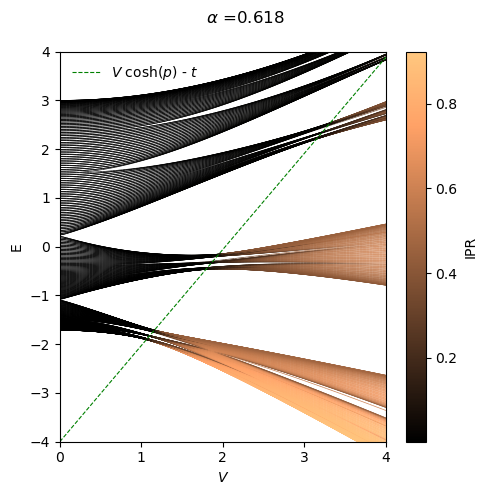

In [67]:
parameters = {
    "V1": 4,
    "V2": 1,
    "Theta_numerator": 170, # usless if alpha is defined

    "alpha": 0.5*(np.sqrt(5) - 1),
    "Theta_denominator": 500,
    
    "nu": 0,
    "k": 0,
    "p": 1.3,

    "periodic_function": funcs[1]
}

v2_linspace = np.linspace(0, 4, 100)
pm_local = deepcopy(parameters)

energies_list = []
ipr_list = []
for v2 in v2_linspace:
    pm_local["V2"] = v2
    h = tbs.makesystem_Biddle(pm_local, False)
    vals, vecs = eigh(h)
    psi_sq = np.abs(vecs)**2
    ipr = np.sum(psi_sq**2, axis=0)
    energies_list.append(vals)
    ipr_list.append(ipr)

energies = np.array(energies_list).T
iprs = np.array(ipr_list).T

X = np.tile(v2_linspace, (energies.shape[0], 1))
Y = energies
points = np.array([X, Y]).T.swapaxes(0, 1)
segments = np.stack([points[:, :-1], points[:, 1:]], axis=2)
segments = segments.reshape(-1, 2, 2)
segment_colors = (iprs[:, :-1] + iprs[:, 1:])/2
segment_colors = segment_colors.flatten()

fig, ax = plt.subplots(figsize=(5, 5))
lc = LineCollection(segments, cmap='copper', rasterized=True) #type:ignore
lc.set_array(segment_colors)
lc.set_linewidth(0.5)
ax.add_collection(lc)
ax.set_xlim(v2_linspace.min(), v2_linspace.max())

ax.set_xlabel(r"$V$")
ax.set_ylabel("E")
ax.plot(v2_linspace, v2_linspace*np.cosh(parameters["p"]) - parameters["V1"],
        color = 'g', linestyle = '--',linewidth=0.8, label = r"$V$ $\cosh(p)$ - $t$")
ax.set_ylim(-4, 4)
ax.legend(loc='upper left', frameon=False)
cbar = plt.colorbar(lc, ax=ax)
cbar.set_label(r"IPR")
fig.suptitle(r"$\alpha$ =" + f"{parameters["alpha"]:.4}")
plt.tight_layout()
plt.savefig("Biddle_EV.png")
plt.show()

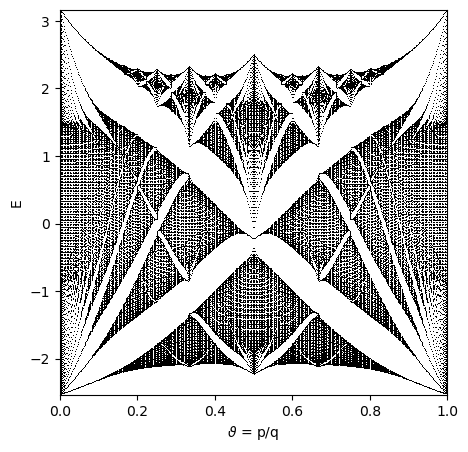

In [59]:
parameters = {
    "V1": 1,
    "V2": 2,
    "Theta_numerator": 170, # usless if alpha is defined

    #"alpha": 0,
    "Theta_denominator": 500,
    
    "nu": 0,
    "k": 0,
    "p": 1,

    "periodic_function": funcs[1]
}

thetas, energies = tbs.spectrum(
    pm = parameters,
    makesystem = tbs.makesystem_Biddle,
    step=1, # step of the Theta_numerator [0->Theta_denominator]
    plot=True, # whether to plot E(phase),
    name = "spectrum_Biddle"
    )

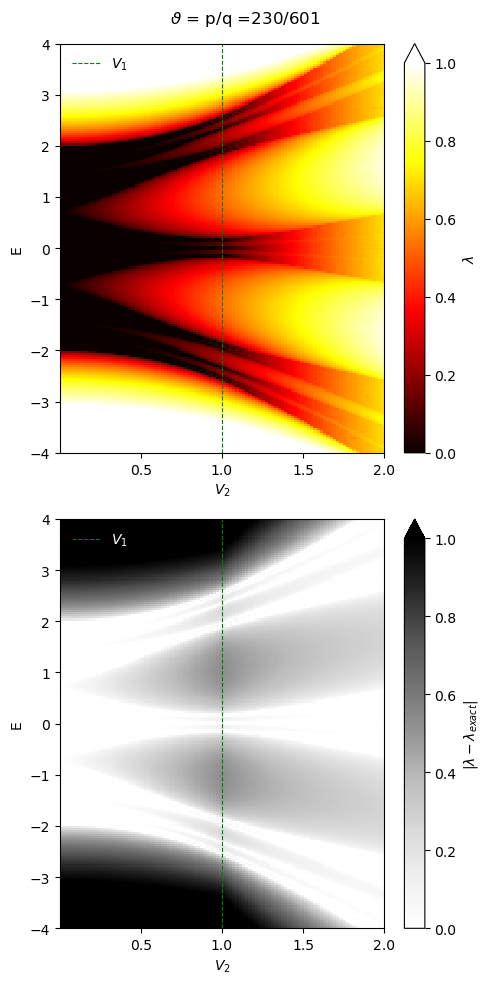

In [27]:
parameters = {
    "V1": 1.0,
    "V2": 1.0,
    "Theta_numerator": 230,
    "Theta_denominator": 601,
    "nu": 0,
    "k": 0,
    "periodic_function": funcs[1]
}

v2_linspace = np.linspace(0.0001, 2, 100)
E_max_limit = 4
energy_steps = 200
global_energies = np.linspace(-E_max_limit, E_max_limit, energy_steps)
gamma_map = np.zeros((len(v2_linspace), len(global_energies)))
gamma_map_exact = np.zeros((len(v2_linspace), len(global_energies)))

pm_local = deepcopy(parameters)
for i, v2 in enumerate(v2_linspace):
    pm_local["V2"] = v2
    sys = tbs.makesystem(pm_local)
    #k, e = tbs.bands(pm_local, n_k = 20)
    #eigenvalues = e.flatten()
    eigenvalues = eigh(sys, eigvals_only=True)
    
    gammas = tbs.gamma_but_different(
        pm_local,
        eigenvalues,
        energies_to_calculate_for=global_energies
    )

    gamma_map[i, :] = gammas
    gamma_map_exact[i, :] = np.ones_like(gammas)*np.log(pm_local["V2"]/pm_local["V1"]) if pm_local["V2"] > pm_local["V1"] else 0

fig, ax = plt.subplots(2, 1, figsize=(5, 10))
data_to_plot = gamma_map.T
data_to_plot2 = gamma_map_exact.T
extent = (v2_linspace.min(), v2_linspace.max(), global_energies.min(), global_energies.max())

im = ax[0].imshow(data_to_plot,
            extent=extent,
            origin='lower',
            aspect='auto',
            cmap='hot', # 'inferno', 'viridis', 
            interpolation='nearest',
            vmin = 0,
            vmax = 1)

ax[0].set_xlabel(r"$V_2$")
ax[0].set_ylabel("E")
ax[0].axvline(x=pm_local["V1"], color='g', linestyle='--', linewidth=0.8, label=r"$V_1$")
fig.suptitle(r"$\vartheta$ = p/q =" + f"{pm_local["Theta_numerator"]}/{pm_local["Theta_denominator"]}")
ax[0].legend(loc='upper left', frameon = False)
cbar = plt.colorbar(im, ax=ax[0], extend='max')
cbar.set_label(r"$\lambda$")


im = ax[1].imshow(np.abs(data_to_plot - data_to_plot2),
            extent=extent,
            origin='lower',
            aspect='auto',
            cmap='Greys', # 'inferno', 'viridis', 
            interpolation='nearest',
            vmin = 0,
            vmax = 1)


ax[1].set_xlabel(r"$V_2$")
ax[1].set_ylabel("E")
ax[1].axvline(x=pm_local["V1"], color='g', linestyle='--', linewidth=0.8, label=r"$V_1$")
ax[1].legend(loc='upper left', frameon = False, labelcolor = 'w')
cbar = plt.colorbar(im, ax=ax[1], extend='max')
cbar.set_label(r"$|\lambda - \lambda_{exact}|$")

plt.tight_layout()
plt.savefig("lambda_factor.pdf")
plt.show()